# Lab 2 Data Visualization and InterpretationUsing Matplotlib-I

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv("House_Rent_Dataset.csv")
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [3]:
df.shape

(4746, 12)

In [4]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [6]:
df["Area Type"].unique()

array(['Super Area', 'Carpet Area', 'Built Area'], dtype=object)

In [7]:
df["Area Locality"].unique()

array(['Bandel', 'Phool Bagan, Kankurgachi', 'Salt Lake City Sector 2',
       ..., 'BN Reddy Nagar', 'Godavari Homes, Quthbullapur',
       'Manikonda, Hyderabad'], shape=(2235,), dtype=object)

In [8]:
df["Furnishing Status"].value_counts()

Furnishing Status
Semi-Furnished    2251
Unfurnished       1815
Furnished          680
Name: count, dtype: int64

In [9]:
df["City"].value_counts()

City
Mumbai       972
Chennai      891
Bangalore    886
Hyderabad    868
Delhi        605
Kolkata      524
Name: count, dtype: int64

## 1.Line Plot

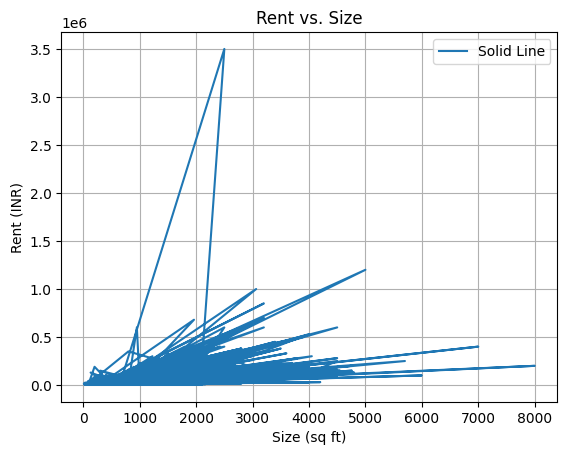

In [10]:
plt.plot(df['Size'], df['Rent'], linestyle='-', label='Solid Line')
plt.grid(True)

plt.title("Rent vs. Size") 
plt.xlabel("Size (sq ft)") 
plt.ylabel("Rent (INR)")
plt.legend(loc='upper right')
plt.show()

# 2. Bar Chart

In [11]:
avg =df.groupby('Furnishing Status')['Rent'].mean()
print("Average : ",avg)

Average :  Furnishing Status
Furnished         56110.305882
Semi-Furnished    38718.810751
Unfurnished       22461.635813
Name: Rent, dtype: float64


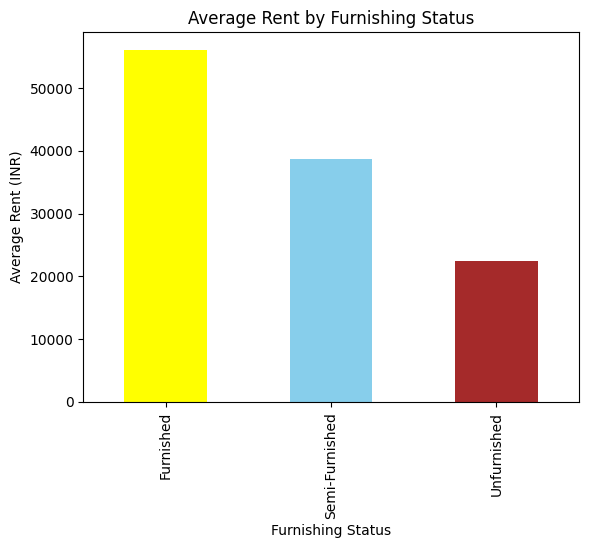

In [12]:
colors = ['yellow', 'skyblue', 'brown'] 
avg.plot(kind='bar', color=colors)


plt.title("Average Rent by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Average Rent (INR)")

plt.show()

# 3. Scatter Plot

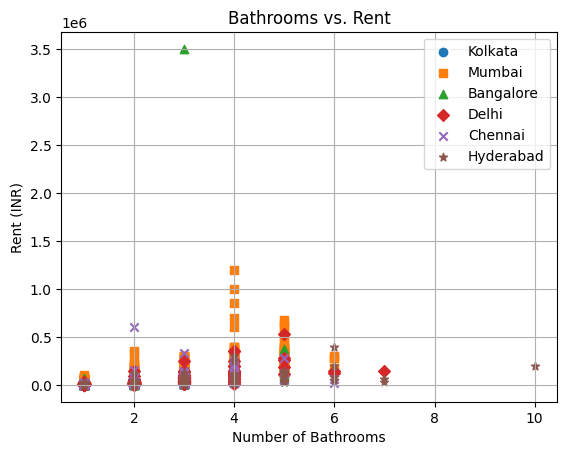

In [13]:


Cities = df['City'].unique()
markers = ['o', 's', '^', 'D', 'x', '*', 'P', 'v']

for city, marker in zip(Cities, markers):
    city_data = df[df['City'] == city]
    plt.scatter(city_data['Bathroom'],city_data['Rent'],marker=marker,label=city)
    
plt.title("Bathrooms vs. Rent")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Rent (INR)")
plt.legend()
plt.grid(True)
plt.show()


# 4. Histogram

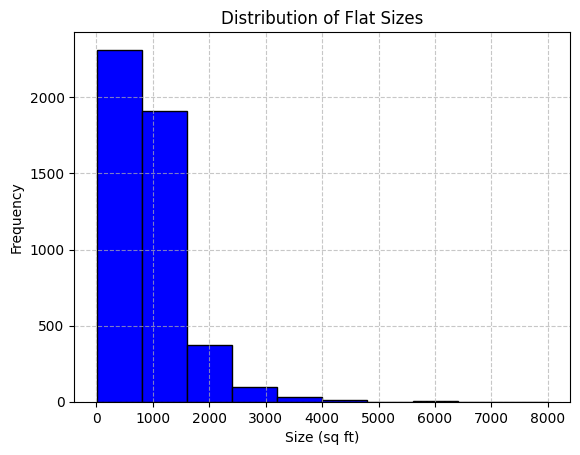

In [14]:
plt.hist(df["Size"], bins=10, color='blue', edgecolor='black')

# Title and axis labels
plt.title("Distribution of Flat Sizes")
plt.xlabel("Size (sq ft)")
plt.ylabel("Frequency")

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Show plot
plt.show()

# 5. Stacked Bar Chart

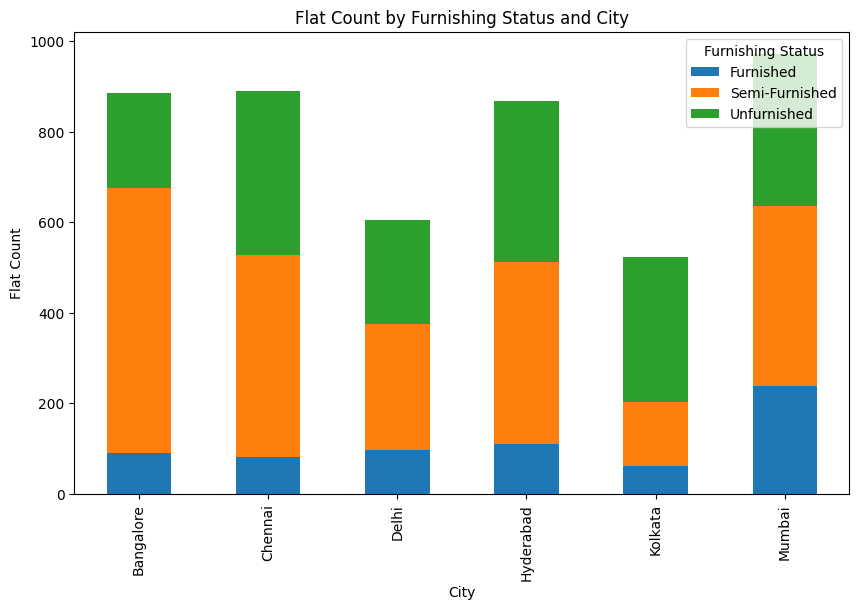

In [15]:
# Group by City and Furnishing Status, count flats
flat_counts = df.groupby(["City", "Furnishing Status"]).size().unstack()\

# Create stacked bar chart
flat_counts.plot(kind="bar", stacked=True, figsize=(10,6))

# Title and axis labels
plt.title("Flat Count by Furnishing Status and City")
plt.xlabel("City")
plt.ylabel("Flat Count")

# Show plot
plt.show()

## 6. Pie Chart

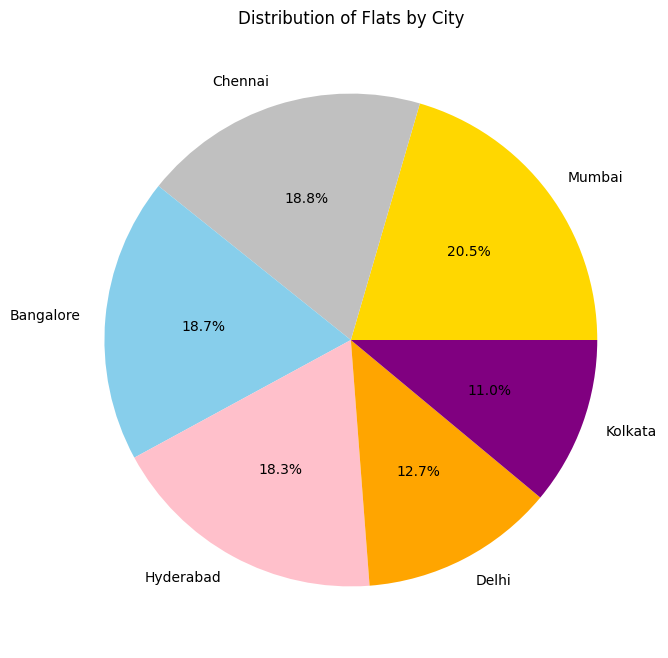

<Figure size 640x480 with 0 Axes>

In [16]:
city_counts = df['City'].value_counts()
colors = ['gold', 'silver', 'skyblue', 'pink', 'orange', 'purple']
plt.figure(figsize=(8, 8))
plt.pie(city_counts, labels=city_counts.index, autopct='%1.1f%%', colors=colors)
plt.title("Distribution of Flats by City")
plt.show()
plt.savefig("Pie_Chart")

## 7. Stacked Plotm

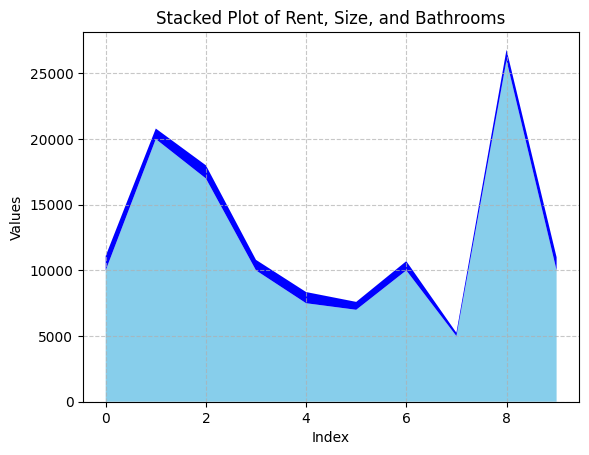

In [17]:
#Select first 10 rows
subset = df.head(10)


# Create stacked plot 
plt.stackplot( subset.index, subset["Rent"], 
               subset["Size"], 
               subset["Bathroom"], 
               labels=["Rent", "Size", "Bathrooms"], 
               colors=["skyblue", "blue", "black"] )


# Title and labels 
plt.title("Stacked Plot of Rent, Size, and Bathrooms") 
plt.xlabel("Index") 
plt.ylabel("Values")

# Grid 
plt.grid(True, linestyle="--", alpha=0.7)

# Show plot 
plt.show()


In [18]:
df = pd.read_csv("House_Rent_Dataset.csv")
pivot_city_bhk = pd.pivot_table(
 df,
 values='Rent',
 index='City',
 columns='BHK',
 aggfunc='mean'
)
print(pivot_city_bhk) 


BHK                   1             2              3              4  \
City                                                                  
Bangalore   9368.333333  16122.041763   61988.580247  113043.478261   
Chennai     8455.926380  15701.692149   35741.913636   96350.000000   
Delhi      11332.500000  18878.342520   44141.558442  117455.583333   
Hyderabad   9753.793103  13877.652466   29337.650206   95730.769231   
Kolkata     6897.183099  10687.847826   19666.576087   26909.090909   
Mumbai     29218.843206  57768.195187  122009.242291  279109.589041   

BHK                    5         6  
City                                
Bangalore            NaN       NaN  
Chennai     75000.000000  170000.0  
Delhi      190000.000000       NaN  
Hyderabad  131666.666667   45000.0  
Kolkata     23750.000000   20000.0  
Mumbai     442727.272727       NaN  


In [19]:
# Loc

df.loc[:, ["Rent", "City", "BHK"]]


,Rent,City,BHK
0,10000,Kolkata,2
1,20000,Kolkata,2
2,17000,Kolkata,2
3,10000,Kolkata,2
4,7500,Kolkata,2
...,...,...,...
4741,15000,Hyderabad,2
4742,29000,Hyderabad,3
4743,35000,Hyderabad,3
4744,45000,Hyderabad,3


In [20]:
df.loc[df["Rent"] > 20000]


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
8,2022-06-07,2,26000,800,1 out of 2,Carpet Area,"Palm Avenue Kolkata, Ballygunge",Kolkata,Unfurnished,Bachelors,2,Contact Agent
10,2022-05-23,3,25000,1200,1 out of 4,Carpet Area,"Action Area 1, Rajarhat Newtown",Kolkata,Semi-Furnished,Bachelors/Family,2,Contact Agent
15,2022-06-01,3,40000,1286,1 out of 1,Carpet Area,New Town Action Area 1,Kolkata,Furnished,Bachelors/Family,2,Contact Owner
34,2022-05-10,3,22000,1100,2 out of 3,Carpet Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
38,2022-06-10,2,21000,900,1 out of 2,Carpet Area,Bansdroni,Kolkata,Semi-Furnished,Bachelors,2,Contact Owner
...,...,...,...,...,...,...,...,...,...,...,...,...
4735,2022-06-08,3,35000,1250,4 out of 5,Super Area,Raj Bhawan Road,Hyderabad,Furnished,Bachelors,2,Contact Owner
4739,2022-07-06,2,25000,1040,2 out of 4,Carpet Area,Gachibowli,Hyderabad,Unfurnished,Bachelors,2,Contact Owner
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent


In [23]:
print("\nUsing iloc (position):")
print(df.iloc[10:15])


Using iloc (position):
     Posted On  BHK   Rent  Size            Floor    Area Type  \
10  2022-05-23    3  25000  1200       1 out of 4  Carpet Area   
11  2022-06-07    1   5000   400       1 out of 1  Carpet Area   
12  2022-05-14    1   6500   250       1 out of 4  Carpet Area   
13  2022-05-09    1   5500   375       1 out of 2  Carpet Area   
14  2022-05-05    3   8500   900  Ground out of 2  Carpet Area   

                      Area Locality     City Furnishing Status  \
10  Action Area 1, Rajarhat Newtown  Kolkata    Semi-Furnished   
11                        Keshtopur  Kolkata       Unfurnished   
12               Tarulia, Keshtopur  Kolkata         Furnished   
13                    Dum Dum Metro  Kolkata       Unfurnished   
14                  Paschim Barisha  Kolkata       Unfurnished   

    Tenant Preferred  Bathroom Point of Contact  
10  Bachelors/Family         2    Contact Agent  
11  Bachelors/Family         1    Contact Agent  
12         Bachelors         1  